# AI Assisted Side Channel Analysis Lecture

## Disclaimer!!!

Lots of this lecture builds off other open-source material, not limited to
- [ChipWhisperer Jupyter Notebook Repository](https://github.com/newaetech/chipwhisperer-jupyter)
- [SimpleCrypto SCALIB](https://github.com/simple-crypto/SCALib)
- [Google SCAAML and Sedpack](https://github.com/google/scaaml)
- [Hardware hacker Handbook Tutorials](https://github.com/HardwareHackingHandbook/notebooks/tree/main/labs)

Please follow all licenses for each material, and only distribute / use code from this lesson as an educational tool.
Please understand and follow the LICENSE file in this repo.

### Software Needed for Lesson
- python >= 3.11 (I'm using 3.12)
    - Highly recommend you use a python virtual environment tool (Mamba, Conda, Pip venv)
- Jupyter tool for notebook (I'm using labs, but a pure notebook should work)
- Python libraries (all dependencies will install from these). Just use `pip install <package-name>`
    - sedpack
    - scalib
    - matplotlib
- Highly recommend giving ChipWhisperer a peak
    - Great intro tutorials for many hardware attacks https://github.com/newaetech/chipwhisperer-jupyter


### Papers to Read
Many great conferences, some good journals.
The International Association for Cryptologic Research (IACR) is a leader in the field, and has multiple proceedings.
Lots of focus on open-source results, and many great software/hardware demos
- [Generalized Power Attacks against Crypto Hardware using Long-Range Deep Learning](https://tches.iacr.org/index.php/TCHES/article/view/11685)
- [TPUXtract: An Exhaustive Hyperparameter Extraction Framework](https://tches.iacr.org/index.php/TCHES/article/view/11923)
- [A Comparison of Multi-task Learning and Single-Task Learning Approaches](https://iacr.steepath.eu/2023/611-AComparisonofMultitasklearningandSingletasklearningApproaches.pdf)
- [Non-Profiled Deep Learning-based Side-Channel attacks with Sensitivity Analysis](https://tches.iacr.org/index.php/TCHES/article/view/7387)

### Great Books
- [Embedded Cryptography 1, 2 and 3](https://www.wiley.com/en-us/Embedded+Cryptography+1-p-9781394351862)
- [The Hardware Hacking Handbook](https://nostarch.com/hardwarehacking)

### Datasets and Benchmarks for SCA
- ASCAD (v1 and v2)
- CHES Challenege 2024
- ChipWhisperer Open-source Datasets
- Simulated datasets (this tutorial)

# Lets Get Started

## Background of SCA
Side Channel Analysis (SCA) is 

Why Crypto / AES

In [30]:
import numpy as np
import random
import pylab as py
import matplotlib.pyplot as plt

# Make this lab repeatable
random.seed(42) 
np.random.seed(42)

#Generate a random lookup table as sbox
lookup = [x for x in range(256)]
random.shuffle(lookup)

# Create a simulated power trace, based on data in (din)
def measure_power(din):
    #secret byte
    skey = 0b101010 # 0x42
    
    #Calculate result
    res = lookup[din ^ skey]
    
    #Generate some arbitrary random data, not necessarily around zero
    b = 148
    a = 154    
    basetrace = (b - a) * np.random.random_sample(50) + a
    
    #Determine number of 1's in result (Hamming Weight), create appropriately sized spike
    time_of_leakage = 35
    basetrace[time_of_leakage] += bin(res).count('1') - 4 # On average, HW=4, so we minus it out
        
    return basetrace

In [28]:
# Create a number of simulated traces and input data
def gen_traces(number_traces):    
    traces = np.array([None] * number_traces)
    input_data = np.random.randint(0, 256, number_traces)

    for d in range(0, number_traces):
        traces[d] = np.array(measure_power(input_data[d]))
    return (input_data, traces)
    
(input_data, traces) = gen_traces(1000)

In [29]:
#what is the data?

print(f"{input_data.shape=}")
print(f"{traces.shape=}")
print(f"{traces[0].shape=}")

#some sample data
print(input_data[:10])
print(input_data[500:510])

#some sample plots

input_data.shape=(1000,)
traces.shape=(1000,)
traces[0].shape=(50,)
[102 179  92  14 106  71 188  20 102 121]
[190 252 212 159 214 160 255  66 127  17]


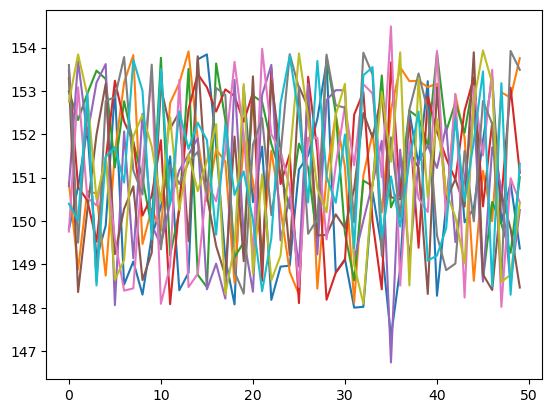

In [36]:
#plot a few traces
plt.figure()

temp_x = np.arange(50)

for i in range(10):
    plt.plot(temp_x, traces[i])

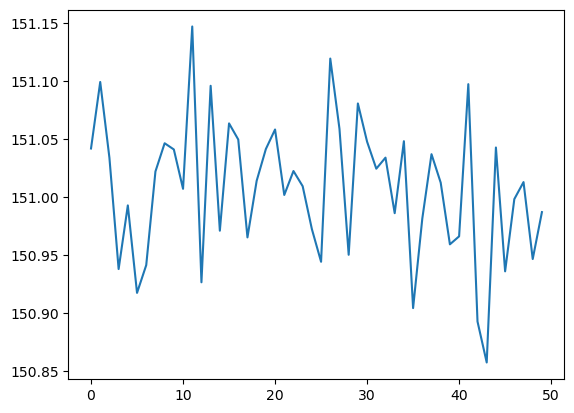

In [39]:
#plot the average trace
trace_avg = np.mean(traces)
plt.figure()
plt.plot(temp_x, trace_avg)

# HW
Lets look at a popular choice to model intermediate values, called Hamming Weights.

This data is taken from the ChipWhisperer Jupyter notebook tutorials, and are fully simulated traces

(100, 5000)


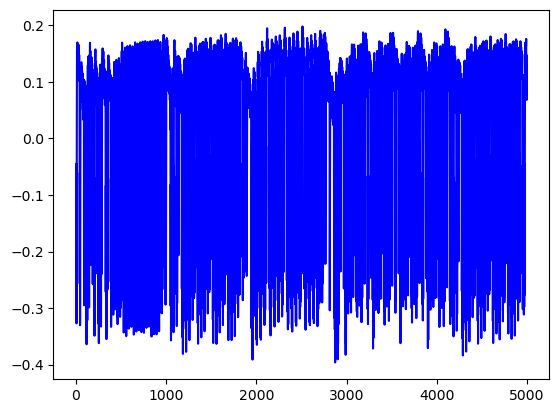

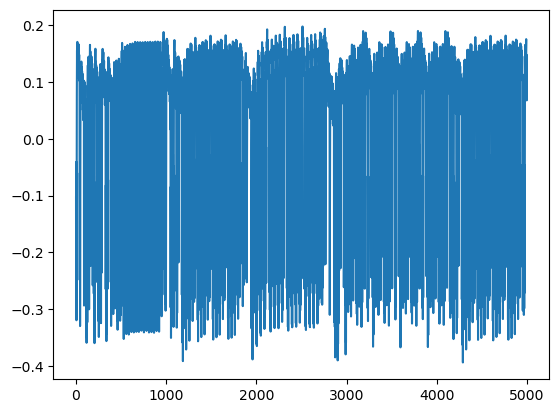

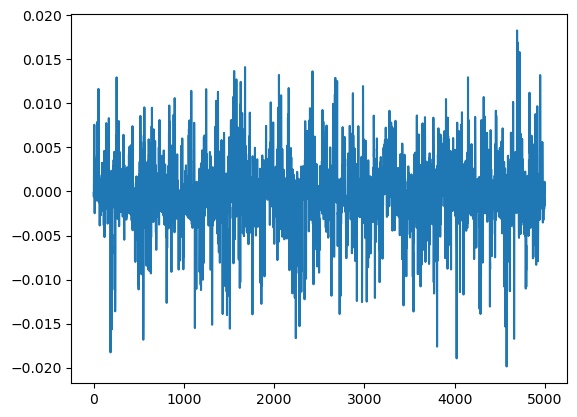

In [81]:
from cwtraces import sca101_lab_data
import chipwhisperer as cw

data = sca101_lab_data["lab3_1"]()
trace_array  =  data["trace_array"]
textin_array = data["textin_array"]

print(trace_array.shape)

#look at avergage trace from simulated hardware

plt.figure()
plt.plot(np.arange(trace_array.shape[1]), trace_array[50], 'b')
plt.figure()
plt.plot(np.arange(trace_array.shape[1]), np.mean(trace_array, axis=0))
plt.figure()
plt.plot(np.arange(trace_array.shape[1]), np.mean(trace_array, axis=0) - trace_array[50])

In [138]:
#split arrays into 0s and 1s
ones = []
zeros = []

byte = 0

for i in range(trace_array.shape[0]):
    if textin_array[i][byte] == 0:
        zeros.append(trace_array[i])
    else:
        ones.append(trace_array[i])

zeros = np.array(zeros)
ones = np.array(ones)

zeros_avg = np.mean(zeros, axis=0)
ones_avg = np.mean(ones, axis=0)

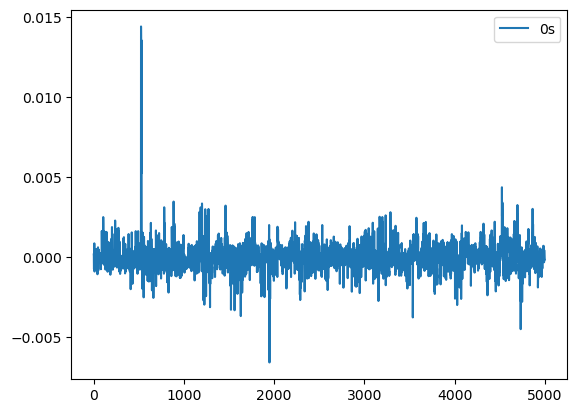

In [139]:
plt.plot(np.arange(zeros_avg.shape[0]), zeros_avg - ones_avg)
plt.legend(["0s - 1s"])

These spikes at the start and near the middle help reflect where data is being manipulated in this trace.
The peaks show the variations. 
Data related to byte 0 and IV 0 is near the front.
Operations relating to byte 0 IV 1 is close to the middle

# SPA

# SNR

(100, 5000) (100, 16)
(16, 5000)


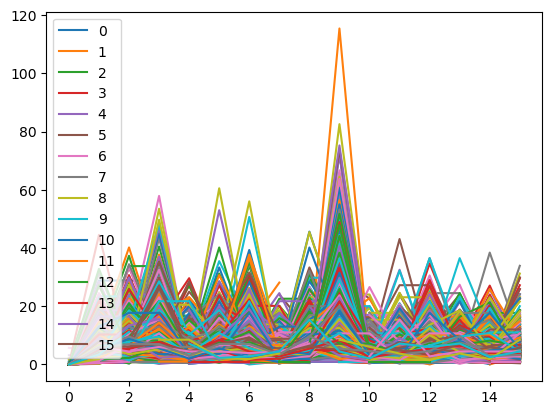

In [182]:
from scalib.metrics import SNR

snr = SNR(nc=256)

print(trace_array.shape, textin_array.shape)

#need to multiple by 100, to translate into int16, to fit library
snr.fit_u((100*trace_array).astype(np.int16), textin_array.astype(np.uint16))
snr_val = snr.get_snr()
print(snr_val.shape)

plt.figure()
plt.plot(snr_val)
plt.legend(np.arange(16))
plt.show()

# TVLA

# CPA

# Template - LDA

# Template - Neural Networks

## Lets Get Meta

Using SCA to break Neural Networks

Model SPA

Parameter Recovery

Other hardware attacks against Neural Networks